# Global Water Watch reservoir timeseries — worked example

This notebook opens the archive, explains how it is laid out, and extracts and
plots the timeseries for one reservoir.

The archive holds satellite-derived **surface water area** for 71,208 lakes and
reservoirs worldwide, 1985–2026, preserved from the
[Global Water Watch](https://www.globalwaterwatch.earth/) platform before it was
decommissioned. See `README.md` for the full description, citation and licence.

Requirements: `pip install xarray netCDF4 pandas matplotlib`

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

NC_PATH = "gww_reservoir_timeseries.nc"

ds = xr.open_dataset(NC_PATH)
ds

<xarray.Dataset> Size: 1GB
Dimensions:                      (geometry_bytes: 315120630, reservoir: 71208,
                                  time: 500, obs_surface_water_area: 44808972)
Coordinates:
  * reservoir                    (reservoir) int64 570kB 1 3 4 ... 92438 92471
  * time                         (time) datetime64[ns] 4kB 1985-01-01 ... 202...
Dimensions without coordinates: geometry_bytes, obs_surface_water_area
Data variables: (12/18)
    geometry_utf8                (geometry_bytes) uint8 315MB ...
    geometry_row_size            (reservoir) int64 570kB ...
    longitude                    (reservoir) float64 570kB ...
    latitude                     (reservoir) float64 570kB ...
    bbox_west                    (reservoir) float64 570kB ...
    bbox_east                    (reservoir) float64 570kB ...
    ...                           ...
    grand_id                     (reservoir) <U4 1MB ...
    download_ok                  (reservoir) int8 71kB ...
    surface_water_area_row_size  (reservoir) int32 285kB ...
    surface_water_area_monthly   (reservoir, time) float32 142MB ...
    surface_water_area           (obs_surface_water_area) float32 179MB ...
    surface_water_area_time      (obs_surface_water_area) datetime64[ns] 358MB ...
Attributes:
    title:              Global Water Watch reservoir timeseries archive
    summary:            Reservoir surface water timeseries downloaded from th...
    source:             https://api.globalwaterwatch.earth
    references:         https://www.globalwaterwatch.earth/
    featureType:        timeSeries
    Conventions:        CF-1.10
    history:            2026-09-07T11:10:29.087224+00:00 merged 214 chunks by...
    n_reservoirs:       71208
    monthly_variables:  surface_water_area_monthly
    ragged_variables:   surface_water_area

## How the archive is laid out

There are two kinds of timeseries in the file, stored differently.

**1. Monthly aggregates — a dense 2-D grid.**
Every reservoir shares the same monthly calendar, so `surface_water_area_monthly`
is simply `(reservoir, time)`. Months with no observation are `NaN`. You index it
the obvious way: `ds["surface_water_area_monthly"].sel(reservoir=123)`.

**2. Raw satellite observations — a ragged array.**
Each reservoir is observed at its own overpass times, shared with no other
reservoir. On a common time axis they would form a grid that is over 99.9%
missing, so instead every reservoir's observations are laid end to end along one
flat dimension (the CF *contiguous ragged array* representation):

```
reservoir index :  [   0   ][      1      ][  2  ] ...
row_size        :     25          371        238
                      ↓            ↓           ↓
obs_...         :  |---25---|-----371-----|-238-|     one flat dimension
surface_water_area_time : timestamp of every element
surface_water_area      : value of every element
```

`surface_water_area_row_size(reservoir)` gives each reservoir's block length, in
reservoir order. The cumulative sum gives the slice boundaries — that is all the
helper further down does.

**Everything else** (`longitude`, `latitude`, `bbox_*`, `name`, `grand_id`,
`geometry_row_size`, `download_ok`, …) is one value per reservoir.

Areas are in **m²** throughout.

In [2]:
print("dimensions:", dict(ds.sizes))
print()
print("monthly variables:", ds.attrs["monthly_variables"])
print("ragged variables :", ds.attrs["ragged_variables"])
print()
print(ds.attrs["history"])

dimensions: {'geometry_bytes': 315120630, 'reservoir': 71208, 'time': 500, 'obs_surface_water_area': 44808972}

monthly variables: surface_water_area_monthly
ragged variables : surface_water_area

2026-09-07T11:10:29.087224+00:00 merged 214 chunks by download_gww.py


## What is in the file?

Per-reservoir metadata only — this stays fast even across all 71k reservoirs,
because no timeseries data is touched.

In [3]:
overview = pd.DataFrame({
    "reservoir": ds["reservoir"].values,
    "name": [str(n) for n in ds["name"].values],
    "lon": ds["longitude"].values.round(4),
    "lat": ds["latitude"].values.round(4),
    "source": [str(s) for s in ds["source_name"].values],
    "n_raw_obs": ds["surface_water_area_row_size"].values,
    "ok": ds["download_ok"].values,
}).set_index("reservoir")

print(f"{len(overview):,} reservoirs")
print(f"{(overview['ok'] == 0).sum():,} with download_ok = 0 (no data archived for them)")
overview.head(20)

71,208 reservoirs
0 with download_ok = 0 (no data archived for them)


,name,lon,lat,source,n_raw_obs,ok
reservoir,,,,,,
1,,-84.0946,30.8625,osm_way,25,1
3,,116.0158,-33.9785,osm_way,371,1
4,,143.3099,-37.5180,osm_way,238,1
5,,57.0989,29.4671,osm_way,203,1
6,,5.8756,51.9344,osm_way,397,1
7,,-117.3488,43.7176,osm_way,49,1
8,,-5.7843,39.8859,osm_way,573,1
9,,90.2507,28.6521,osm_way,92,1
10,Lago della Vacca,10.4392,45.9549,osm_way,67,1


## Pick a reservoir

Change `RESERVOIR_ID` to any id from the table above. The default picks whichever
reservoir has the most observations, so the plots have something to show.

In [4]:
RESERVOIR_ID = int(overview["n_raw_obs"].idxmax())   # <- edit this

meta = overview.loc[RESERVOIR_ID]
print(f"reservoir {RESERVOIR_ID}: {meta['name'] or '(unnamed)'}")
print(f"  location : {meta['lat']:.4f} N, {meta['lon']:.4f} E   (source: {meta['source']})")
print(f"  raw obs  : {meta['n_raw_obs']:,}")

reservoir 72195: (unnamed)
  location : 34.2865 N, -114.2297 E   (source: HydroLAKES)
  raw obs  : 2,737


### The monthly series — a straightforward selection

In [5]:
monthly = (
    ds["surface_water_area_monthly"]
    .sel(reservoir=RESERVOIR_ID)
    .to_series()
    .dropna()                    # drop months outside this reservoir's record
)

print(f"{len(monthly)} months, {monthly.index[0]:%Y-%m} to {monthly.index[-1]:%Y-%m}")
monthly.head()

500 months, 1985-01 to 2026-08


time
1985-01-01    1518170.625
1985-02-01    1518170.625
1985-03-01    1518170.625
1985-04-01    1518170.625
1985-05-01    1518170.625
Name: surface_water_area_monthly, dtype: float32

### The raw series — unpack the ragged array

`row_size` gives the block lengths; the cumulative sum gives the offsets.

Note the indexing order: `ds[var][sl].values`, **not** `ds[var].values[sl]`.
The first reads just this reservoir's block from disk; the second would load
every observation in the file (~500 MB) to return one reservoir's data.

In [6]:
def ragged_slice(ds, variable, reservoir_id):
    """(times, values) for one reservoir from a contiguous ragged array."""
    ids = ds["reservoir"].values
    hits = np.flatnonzero(ids == int(reservoir_id))
    if hits.size == 0:
        raise KeyError(f"reservoir {reservoir_id} is not in this file")
    i = int(hits[0])

    row_size = ds[f"{variable}_row_size"].values
    start = int(row_size[:i].sum())
    sl = slice(start, start + int(row_size[i]))

    return ds[f"{variable}_time"][sl].values, ds[variable][sl].values


times, values = ragged_slice(ds, "surface_water_area", RESERVOIR_ID)
raw = pd.Series(values, index=pd.DatetimeIndex(times), name="surface_water_area")

print(f"{len(raw)} observations, {raw.index[0]:%Y-%m-%d} to {raw.index[-1]:%Y-%m-%d}")
raw.head()

2737 observations, 1985-01-03 to 2026-08-29


1985-01-03 17:40:00    1537021.000
1985-01-19 17:40:00    1523306.875
1985-05-11 17:39:00    1518170.625
1985-08-15 17:39:00    1494433.000
1985-09-16 17:39:00    1492949.750
Name: surface_water_area, dtype: float32

## Plot the timeseries and its anomaly

Two panels sharing a time axis:

- **top** — individual satellite observations (dots) against the monthly
  aggregate (line);
- **bottom** — the **monthly anomaly**: each month minus the mean for that
  calendar month. This removes the seasonal cycle, so what is left is how full
  the reservoir was *for the time of year* — wet and dry periods, drawdown,
  long-term trend.

The climatology is computed over the **whole record**, not a reference period:
each of the twelve values averages every January, every February and so on that
the reservoir has, 1985 to present. For most reservoirs that is 41–42 years per
calendar month.

Areas are stored in m². Reservoirs in this archive range from farm ponds of a few
hundred m² to major lakes, so the cell below picks a readable unit rather than
assuming km².

climatology baseline: 1985-01 to 2026-08, 500 months
  years averaged per calendar month: 41-42


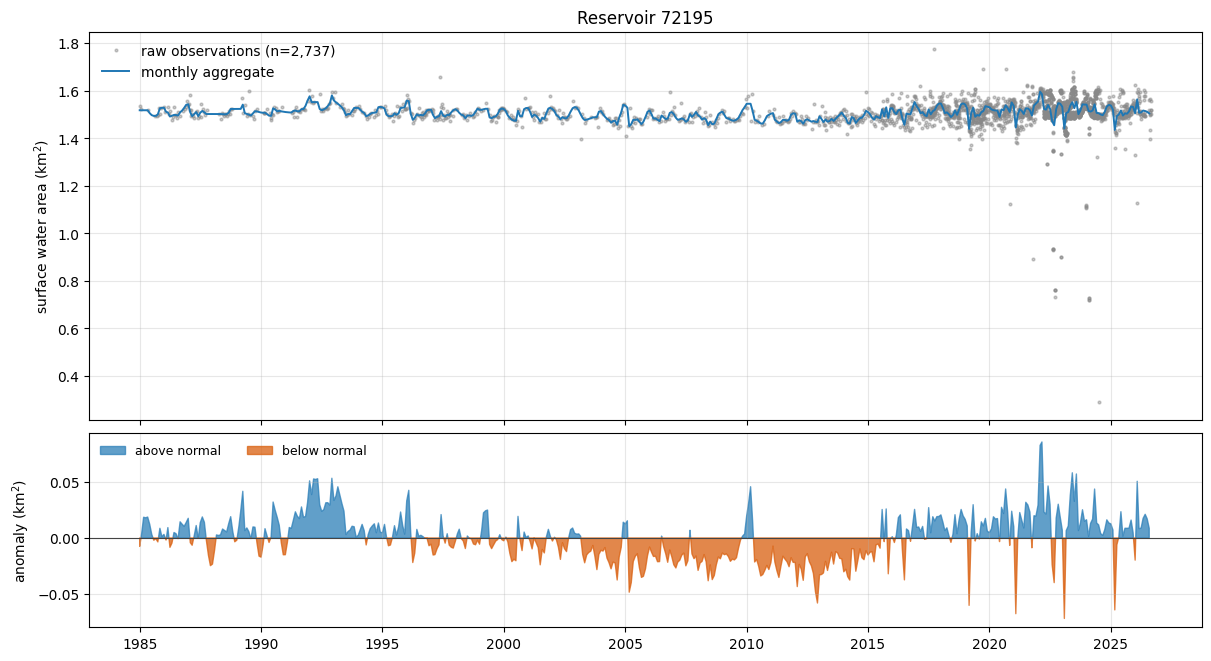

In [7]:
def area_unit(values_m2):
    """Pick m2 / ha / km2 based on the magnitude of the data.

    Returns (divisor, unit label).
    """
    typical = np.nanmedian(np.abs(values_m2))
    if typical >= 1e6:
        return 1e6, "km$^2$"
    if typical >= 1e4:
        return 1e4, "ha"
    return 1.0, "m$^2$"


scale, unit = area_unit(monthly.values)
label = f"surface water area ({unit})"

# The climatology spans the WHOLE record: each of the 12 values is the mean of
# every January, every February and so on that this reservoir has, from 1985 to
# the end of the series. Nothing is restricted to a reference period.
# reindex() then lines those 12 values up with the ~500 timestamps.
climatology = monthly.groupby(monthly.index.month).mean()
anomaly = monthly - climatology.reindex(monthly.index.month).values

per_month = monthly.groupby(monthly.index.month).size()
print(f"climatology baseline: {monthly.index[0]:%Y-%m} to {monthly.index[-1]:%Y-%m}, "
      f"{len(monthly)} months")
print(f"  years averaged per calendar month: {per_month.min()}-{per_month.max()}")

fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(12, 6.5), sharex=True,
    height_ratios=[2, 1], layout="constrained",
)

ax.plot(raw.index, raw.values / scale, ".", ms=4, alpha=0.45, color="#888888",
        label=f"raw observations (n={len(raw):,})")
ax.plot(monthly.index, monthly.values / scale, "-", lw=1.4, color="#1f77b4",
        label="monthly aggregate")

title = f"Reservoir {RESERVOIR_ID}"
if meta["name"]:
    title += f" — {meta['name']}"
ax.set_title(title)
ax.set_ylabel(label)
ax.grid(alpha=0.3)
ax.legend(frameon=False)

a = anomaly / scale
ax2.axhline(0, color="#444444", lw=0.8)
ax2.fill_between(a.index, 0, a.values, where=a.values >= 0,
                 color="#2c7fb8", alpha=0.75, interpolate=True, label="above normal")
ax2.fill_between(a.index, 0, a.values, where=a.values < 0,
                 color="#d95f0e", alpha=0.75, interpolate=True, label="below normal")
ax2.set_ylabel(f"anomaly ({unit})")
ax2.set_xlabel("")
ax2.grid(alpha=0.3)
ax2.legend(frameon=False, ncol=2, loc="upper left", fontsize=9)

The anomaly is the monthly series with its own seasonal cycle removed, so a run
of orange is a genuinely dry stretch rather than simply summer.

Two things to keep in mind when reading it:

- The baseline uses the whole record, but not every reservoir *has* a whole
  record. 46% have all 500 months and the median is 499, so for most the
  climatology rests on 41–42 years per calendar month. A small tail is much
  shorter — the bottom 1% have under ~53 months — and there the baseline is
  correspondingly shakier. The cell above prints the span actually used.
- Observations get much denser from around 2015 (Sentinel-2 joining Landsat), so
  the later part of the record is better constrained. A quieter-looking early
  period may reflect sparser sampling rather than a steadier reservoir.

In [8]:
# How much of the variability the seasonal cycle actually accounted for.
mean_area = monthly.mean()
print(f"mean area        : {mean_area / scale:,.3g} {unit.replace('$^2$', '2')}")
print(f"month-to-month sd: {monthly.std() / scale:,.3g}  "
      f"({monthly.std() / mean_area:.1%} of mean)")
print(f"anomaly sd       : {anomaly.std() / scale:,.3g}  "
      f"({anomaly.std() / mean_area:.1%} of mean)")
print(f"seasonal cycle explains {1 - anomaly.var() / monthly.var():.1%} of the variance")

print()
print("wettest months for the time of year:")
for t, v in anomaly.nlargest(3).items():
    print(f"  {t:%Y-%m}  {v / mean_area:+.1%}")
print("driest months for the time of year:")
for t, v in anomaly.nsmallest(3).items():
    print(f"  {t:%Y-%m}  {v / mean_area:+.1%}")

mean area        : 1.51 km2
month-to-month sd: 0.024  (1.6% of mean)
anomaly sd       : 0.0209  (1.4% of mean)
seasonal cycle explains 23.9% of the variance

wettest months for the time of year:
  2022-03  +5.7%
  2022-02  +5.5%
  2023-06  +3.9%
driest months for the time of year:
  2023-02  -4.8%
  2021-02  -4.5%
  2025-03  -4.3%


Observation density increases markedly from around 2015, when Sentinel-2 joined
Landsat. Apparent changes in variability across that boundary may reflect
sampling rather than the reservoir itself.

## Plot the outline

Outlines are archived as GeoJSON, stored as ragged UTF-8 bytes (see the helper below).

These outlines come from OpenStreetMap and HydroLAKES; OpenStreetMap data is
ODbL-licensed and requires attribution to "© OpenStreetMap contributors" if you
redistribute it. `source_name` says which dataset each reservoir came from.

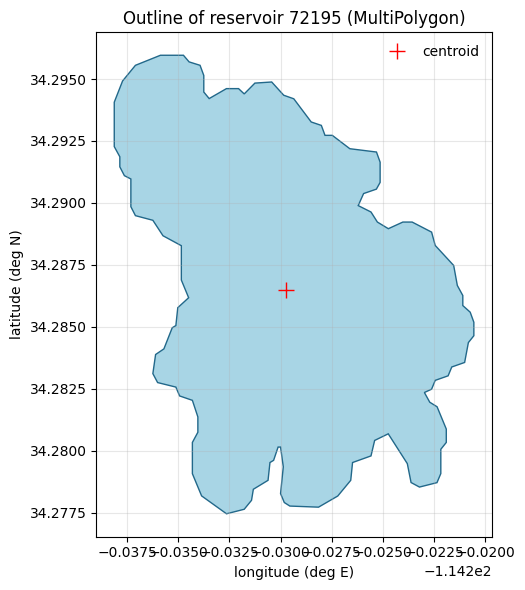

In [9]:
def reservoir_geometry(ds, reservoir_id):
    """The GeoJSON outline of one reservoir, as a dict.

    Outlines are stored the same ragged way as the observations: UTF-8 encoded
    and concatenated along `geometry_bytes`, with `geometry_row_size` giving
    each reservoir's byte count. They range from 271 bytes to 935 kB, and one
    string per reservoir would make xarray widen the variable to a fixed
    935,507 characters across all 71,208 rows -- a 248 GiB allocation.
    """
    ids = ds["reservoir"].values
    hits = np.flatnonzero(ids == int(reservoir_id))
    if hits.size == 0:
        raise KeyError(f"reservoir {reservoir_id} is not in this file")
    i = int(hits[0])

    row_size = ds["geometry_row_size"].values
    start = int(row_size[:i].sum())
    n = int(row_size[i])
    if n == 0:
        return None
    return json.loads(ds["geometry_utf8"][start:start + n].values.tobytes().decode("utf-8"))


geom = reservoir_geometry(ds, RESERVOIR_ID)
i = int(np.flatnonzero(ds["reservoir"].values == RESERVOIR_ID)[0])   # for the centroid

polygons = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]

fig, ax = plt.subplots(figsize=(6, 6))
for poly in polygons:
    for ring_no, ring in enumerate(poly):
        xy = np.asarray(ring)
        # ring 0 is the exterior; any further rings are holes
        ax.fill(xy[:, 0], xy[:, 1],
                facecolor="#a8d5e5" if ring_no == 0 else "white",
                edgecolor="#22688a", lw=1.0, zorder=ring_no)

ax.plot(ds["longitude"].values[i], ds["latitude"].values[i], "r+", ms=12, label="centroid")
ax.set_aspect(1 / np.cos(np.deg2rad(float(ds["latitude"].values[i]))))
ax.set_xlabel("longitude (deg E)")
ax.set_ylabel("latitude (deg N)")
ax.set_title(f"Outline of reservoir {RESERVOIR_ID} ({geom['type']})")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()

## The seasonal cycle itself

The climatology subtracted above, on its own — mean area by calendar month. A
quick check that the series behaves like a reservoir.

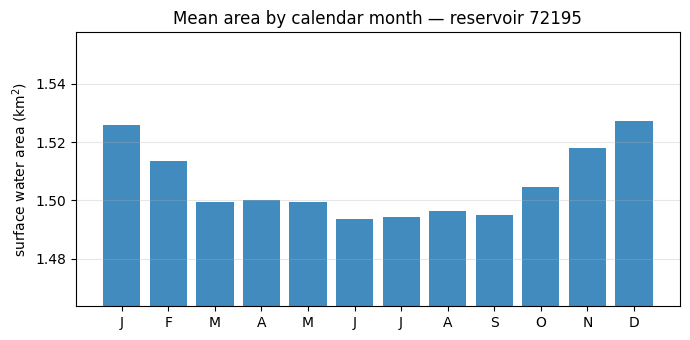

In [10]:
clim = climatology / scale          # the same baseline the anomaly used

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(clim.index, clim.values, color="#1f77b4", alpha=0.85)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set_ylabel(label)
ax.set_title(f"Mean area by calendar month — reservoir {RESERVOIR_ID}")
ax.set_ylim(clim.min() * 0.98, clim.max() * 1.02)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()

## Export

Both series in one table, for use outside xarray.

In [11]:
both = pd.DataFrame({"monthly": monthly}).join(pd.DataFrame({"raw": raw}), how="outer")
both.index.name = "time"

both.to_csv(f"reservoir_{RESERVOIR_ID}.csv")
print(f"wrote reservoir_{RESERVOIR_ID}.csv  ({len(both)} rows)")
both.head()

wrote reservoir_72195.csv  (3230 rows)


,monthly,raw
time,,
1985-01-01 00:00:00,1518170.625,NaN
1985-01-03 17:40:00,NaN,1537021.000
1985-01-19 17:40:00,NaN,1523306.875
1985-02-01 00:00:00,1518170.625,NaN
1985-03-01 00:00:00,1518170.625,NaN


## Many reservoirs at once

The dense monthly grid is built for this. Capped at `MAX_LINES` — the archive
holds ~71k reservoirs, and plotting them all would neither render nor read.

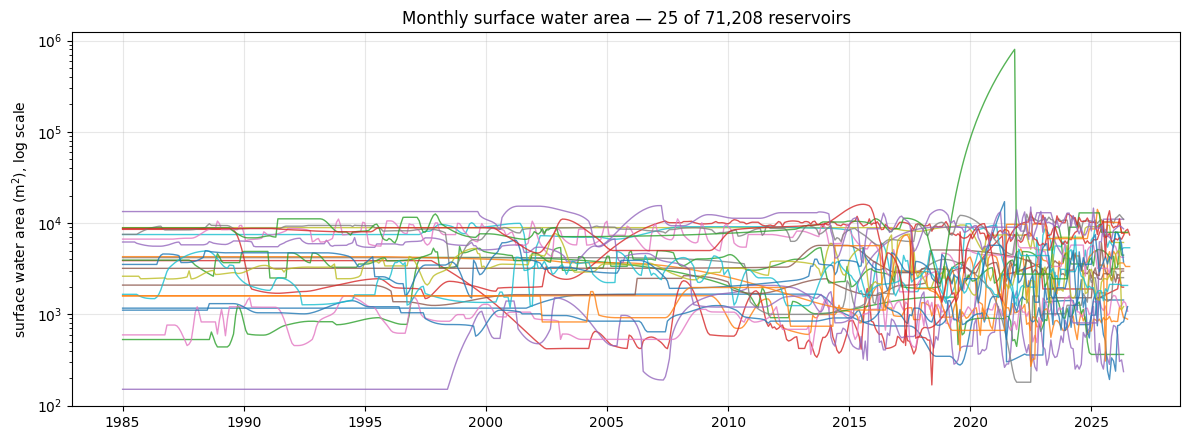

In [12]:
MAX_LINES = 25

ids = ds["reservoir"].values[:MAX_LINES]
block = ds["surface_water_area_monthly"].sel(reservoir=ids)

frame = block.to_pandas().T          # rows = time, columns = reservoir id
scale_all, unit_all = area_unit(block.values)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(frame.index, frame.values / scale_all, lw=1, alpha=0.8)
ax.set_yscale("log")
ax.set_ylabel(f"surface water area ({unit_all}), log scale")
ax.set_title(f"Monthly surface water area — {len(ids)} of {ds.sizes['reservoir']:,} reservoirs")
ax.grid(alpha=0.3)
fig.tight_layout()

## A regional example — reservoirs across France

Everything so far has been one reservoir at a time. The dense monthly grid also
supports regional work: select every reservoir inside a country and average their
anomalies into a single index.

The archive stores coordinates, not countries, so we need a boundary. A coarse
outline of metropolitan France is embedded below — 197 vertices, simplified from
a full-resolution boundary, which reproduces the full-resolution selection to
within one reservoir out of 778. `matplotlib.path` does the point-in-polygon
test, so nothing beyond the notebook's existing dependencies is needed.

In [13]:
from matplotlib.path import Path as MplPath

# Metropolitan France (mainland + Corsica), simplified. Lon/lat degrees, WGS84.
FRANCE_OUTLINE = [
    [(2.535,51.1), (1.568,50.908), (1.412,50.122), (0.137,49.708),
     (0.027,49.509), (0.11,49.425), (0,49.356), (-0.211,49.309),
     (-1.104,49.411), (-1.266,49.547), (-1.165,49.655), (-1.252,49.724),
     (-1.983,49.744), (-1.994,49.678), (-1.884,49.641), (-1.879,49.377),
     (-1.642,49.183), (-1.662,48.886), (-1.546,48.66), (-1.722,48.627),
     (-1.81,48.729), (-2.433,48.691), (-2.714,48.568), (-2.977,48.894),
     (-3.345,48.852), (-3.422,48.912), (-3.645,48.794), (-3.65,48.724),
     (-4.007,48.776), (-4.834,48.522), (-4.801,48.318), (-4.62,48.232),
     (-4.622,48.168), (-4.351,48.184), (-4.774,48.084), (-4.779,48.029),
     (-4.458,47.924), (-4.43,47.784), (-4.021,47.826), (-3.68,47.747),
     (-3.23,47.606), (-3.134,47.46), (-3.062,47.467), (-3.106,47.545),
     (-2.812,47.463), (-2.538,47.488), (-2.557,47.261), (-2.049,47.042),
     (-2.123,46.941), (-2.244,47.051), (-2.335,47.035), (-1.854,46.502),
     (-1.211,46.229), (-1.596,46.246), (-1.112,46.033), (-1.214,46.022),
     (-1.165,45.884), (-1.228,45.997), (-1.442,46.052), (-1.28,45.852),
     (-1.17,45.487), (-1.266,44.5), (-1.464,43.65), (-1.793,43.372),
     (-1.609,43.252), (-1.383,43.253), (-1.441,43.046), (-1.355,43.028),
     (-1.346,43.094), (-1.27,43.118), (-1.31,43.069), (-1.141,43.008),
     (-0.756,42.97), (-0.569,42.782), (-0.314,42.844), (0.001,42.688),
     (0.673,42.692), (0.706,42.859), (1.357,42.718), (1.438,42.603),
     (1.735,42.617), (1.787,42.573), (1.73,42.494), (1.938,42.454),
     (2.015,42.348), (2.255,42.439), (2.675,42.339), (2.673,42.404),
     (2.946,42.481), (3.186,42.436), (3.205,42.505), (3.087,42.602),
     (3.095,42.787), (3.288,43.189), (4.046,43.517), (4.524,43.345),
     (5.202,43.287), (5.375,43.157), (5.771,43.043), (6.191,43.029),
     (6.696,43.181), (6.674,43.293), (6.754,43.385), (7.457,43.716),
     (7.531,43.781), (7.498,43.872), (7.703,44.043), (7.682,44.176),
     (7.359,44.118), (7.004,44.24), (6.888,44.364), (6.949,44.432),
     (6.854,44.534), (6.98,44.69), (7.078,44.68), (7.009,44.84), (6.751,44.91),
     (6.747,45.016), (6.63,45.11), (7.074,45.213), (7.182,45.402),
     (7.005,45.502), (7,45.64), (6.808,45.726), (6.821,45.837), (7.044,45.923),
     (6.875,46.052), (6.899,46.124), (6.791,46.153), (6.866,46.281),
     (6.771,46.356), (6.822,46.428), (6.52,46.456), (6.253,46.36),
     (6.22,46.312), (6.31,46.244), (6.148,46.147), (5.957,46.129),
     (5.964,46.197), (6.124,46.252), (6.17,46.367), (6.065,46.417),
     (6.156,46.546), (6.11,46.578), (6.452,46.775), (6.432,46.929),
     (6.718,47.051), (7.056,47.334), (6.88,47.355), (6.985,47.494),
     (7.402,47.436), (7.584,47.575), (7.511,47.703), (7.616,47.959),
     (7.576,48.125), (7.747,48.333), (7.837,48.641), (8.236,48.968),
     (7.638,49.054), (7.447,49.184), (7.295,49.117), (7.042,49.117),
     (6.921,49.223), (6.737,49.165), (6.556,49.42), (6.241,49.513),
     (5.979,49.451), (5.76,49.561), (5.465,49.492), (5.27,49.689),
     (4.849,49.787), (4.885,49.908), (4.794,49.973), (4.901,50.131),
     (4.828,50.159), (4.687,50.066), (4.695,49.984), (4.14,49.969),
     (4.232,50.079), (4.132,50.131), (4.217,50.263), (4.032,50.352),
     (3.724,50.303), (3.604,50.488), (3.285,50.53), (3.249,50.701),
     (3.15,50.774), (2.834,50.712), (2.615,50.845), (2.535,51.1)],
    [(9.56,42.152), (9.23,41.38), (8.776,41.584), (8.544,42.257),
     (8.746,42.628), (9.39,43.01), (9.56,42.152)],
]


def reservoirs_inside(ds, rings):
    """Ids of every reservoir whose centroid falls inside any of the rings."""
    lon, lat = ds["longitude"].values, ds["latitude"].values
    pts = np.column_stack([lon, lat])
    inside = np.zeros(len(pts), dtype=bool)
    for ring in rings:
        xy = np.asarray(ring)
        # a bounding-box prefilter keeps the polygon test to a few hundred points
        cand = (
            (lon >= xy[:, 0].min()) & (lon <= xy[:, 0].max())
            & (lat >= xy[:, 1].min()) & (lat <= xy[:, 1].max()) & ~inside
        )
        if cand.any():
            inside[cand] = MplPath(xy).contains_points(pts[cand])
    return ds["reservoir"].values[inside]


france_ids = reservoirs_inside(ds, FRANCE_OUTLINE)
france = ds["surface_water_area_monthly"].sel(reservoir=france_ids)

print(f"{len(france_ids)} reservoirs in metropolitan France")
print(f"monthly block: {france.shape} = {france.nbytes / 1e6:.1f} MB")

778 reservoirs in metropolitan France
monthly block: (778, 500) = 1.6 MB


### Where they are

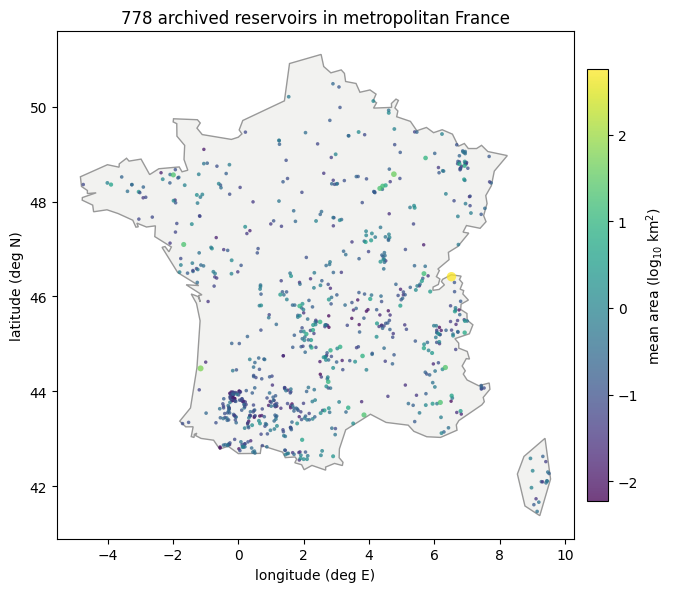

In [14]:
areas = france.mean("time").values
flon = ds["longitude"].sel(reservoir=france_ids).values
flat = ds["latitude"].sel(reservoir=france_ids).values

fig, ax = plt.subplots(figsize=(7, 7.5))
for ring in FRANCE_OUTLINE:
    xy = np.asarray(ring)
    ax.fill(xy[:, 0], xy[:, 1], facecolor="#f2f2f0", edgecolor="#999999", lw=1.0, zorder=0)

sc = ax.scatter(flon, flat, s=6 + 40 * np.sqrt(areas / areas.max()),
                c=np.log10(areas / 1e6), cmap="viridis",
                alpha=0.75, edgecolors="none", zorder=2)
cb = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.02)
cb.set_label("mean area (log$_{10}$ km$^2$)")

ax.set_aspect(1 / np.cos(np.deg2rad(46.5)))
ax.set_xlabel("longitude (deg E)")
ax.set_ylabel("latitude (deg N)")
ax.set_title(f"{len(france_ids)} archived reservoirs in metropolitan France")
fig.tight_layout()

### An average anomaly for the country

**Order matters here.** The anomaly is computed *per reservoir first* — each
against its own climatology over its own whole record — and only then averaged
across reservoirs. The alternative, summing the areas into one national total and
taking an anomaly of that, is not the same thing: it would be an anomaly of the
largest lakes with everything else lost in the rounding, and any reservoir with a
gap would punch a hole in the total.

Each anomaly is then divided by that reservoir's own mean area, so all 778 count
equally. These span four orders of magnitude, 0.006 km² to 569 km², so without
normalising the mean would again be one large lake and 777 rounding errors.

The **area-weighted** line is shown alongside for comparison. The two diverge,
and that divergence is worth understanding — see below.

In [15]:
# Step 1-3 are per reservoir; only step 4 combines them.
clim_fr = france.groupby("time.month").mean("time")        # 1. own climatology
anom_fr = france.groupby("time.month") - clim_fr           # 2. own anomaly
rel_fr = anom_fr / france.mean("time")                     # 3. own mean area
index = (rel_fr.mean("reservoir") * 100).to_series()       # 4. average, last
weights = france.mean("time")
index_w = ((rel_fr * weights).sum("reservoir") / weights.sum() * 100).to_series()
n_contrib = rel_fr.notnull().sum("reservoir").to_series()

roll = index.rolling(12, center=True, min_periods=6).mean()
roll_w = index_w.rolling(12, center=True, min_periods=6).mean()

print(f"reservoirs contributing: min {int(n_contrib.min())}, median {int(n_contrib.median())}")
print(f"index range: {index.min():+.1f}% to {index.max():+.1f}% of normal")

reservoirs contributing: min 327, median 765
index range: -11.1% to +22.2% of normal


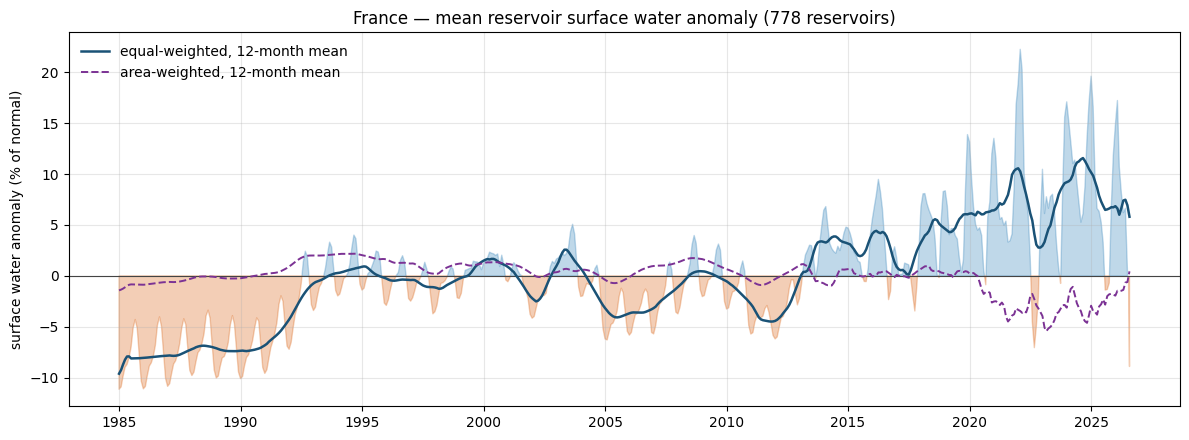

In [16]:
fig, ax = plt.subplots(figsize=(12, 4.5))

ax.axhline(0, color="#444444", lw=0.8)
ax.fill_between(index.index, 0, index.values, where=index.values >= 0,
                color="#2c7fb8", alpha=0.30, interpolate=True)
ax.fill_between(index.index, 0, index.values, where=index.values < 0,
                color="#d95f0e", alpha=0.30, interpolate=True)
ax.plot(roll.index, roll.values, color="#1a5276", lw=1.8,
        label="equal-weighted, 12-month mean")
ax.plot(roll_w.index, roll_w.values, color="#7b3294", lw=1.4, ls="--",
        label="area-weighted, 12-month mean")

ax.set_ylabel("surface water anomaly (% of normal)")
ax.set_title(f"France — mean reservoir surface water anomaly ({len(france_ids)} reservoirs)")
ax.grid(alpha=0.3)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()

### Read this one carefully

The equal-weighted line rises steadily across the record. That is **mostly not
reservoirs filling up** — it is the satellites getting better at seeing small
water bodies. Split the same reservoirs by size and the pattern is unmistakable:

In [17]:
shift = []
q = np.quantile(areas, [0, 0.25, 0.5, 0.75, 1.0])
yearly = (rel_fr * 100).groupby("time.year").mean("time")
years = yearly["year"].values
early, late = (years <= 1994), (years >= 2015)

for i in range(4):
    m = (areas >= q[i]) & (areas <= q[i + 1])
    v = yearly[m].values
    shift.append({
        "size band (km2)": f"{q[i] / 1e6:.3f} - {q[i + 1] / 1e6:.3f}",
        "reservoirs": int(m.sum()),
        "1985-94 (%)": round(float(np.nanmean(v[:, early])), 1),
        "2015-26 (%)": round(float(np.nanmean(v[:, late])), 1),
    })

table = pd.DataFrame(shift)
table["shift (%)"] = (table["2015-26 (%)"] - table["1985-94 (%)"]).round(1)
table

,size band (km2),reservoirs,1985-94 (%),2015-26 (%),shift (%)
0,0.006 - 0.064,195,-3.8,7.6,11.4
1,0.064 - 0.174,194,-9.0,9.1,18.1
2,0.174 - 0.488,194,-8.0,5.5,13.5
3,0.488 - 568.677,195,-0.5,1.2,1.7


The smallest three quartiles shift by +11 to +18 percentage points; the largest
quartile barely moves. A reservoir of 0.06 km² is only a few dozen Landsat pixels
across, so early scenes under-measured it; Sentinel-2's 10 m bands from 2015
resolve it properly. Large lakes were always resolved, so they show almost no
step — which is why the area-weighted line above is so much flatter.

**What this means in practice:**

- Interannual wiggles within a consistent era are meaningful — 2024 stands out as
  wet, matching a notably wet year in France.
- Long-term trends from this index are not, unless you compare like with like:
  restrict to large reservoirs, or to the homogeneous post-2015 period, or
  compare each reservoir only against itself within one era.
- The same caution applies to any regional aggregate built from this archive,
  not just France. Swap `FRANCE_OUTLINE` for another boundary and the behaviour
  will be the same.

## Selecting reservoirs by location

In [18]:
west, east, south, north = 4.0, 8.0, 50.0, 54.0      # the Netherlands, roughly

inside = (
    (ds["longitude"] >= west) & (ds["longitude"] <= east)
    & (ds["latitude"] >= south) & (ds["latitude"] <= north)
)
selected = ds["reservoir"].values[inside.values]

print(f"{len(selected):,} reservoirs in the box")
print(selected[:20])

104 reservoirs in the box
[    6   129   210  1343  1835 31756  4811  4906  5056  6139  7503  9732
 10822 11373 11599 34831  3033 15316 47319 16892]


## Before you draw conclusions

- **Check `download_ok`.** A reservoir with `download_ok = 0` has no timeseries
  here because the archiving request was abandoned — not because the reservoir
  had no data. Treat it as missing, not as empty.
- **Observation density varies over time** (Landsat only before ~2015, Landsat +
  Sentinel-2 after).
- **Series end on different dates.** Each reservoir's record ends at its last
  usable scene, and the final month may aggregate fewer observations than usual.
- **Cloud, ice and shadow** affect water detection; individual observations can be
  outliers, and the monthly aggregate is more robust but not immune.
- **This is area, not storage.** Converting to volume needs an area–volume
  relationship, which is not part of this archive.

See `README.md` for the full caveats, citation and licence.

In [19]:
ds.close()